## 4.4 Model Selection, Underfitting and Overfitting

### 4.4.1 Training Error and Generalization Error

#### 4.4.1.1 Statisitcs Theory

#### 4.4.1.2 Model Complexity

### 4.4.2 Model Selection

#### 4.4.2.1 Validation Set

#### 4.4.2.2 K-Fold Validation

### 4.4.3 Underfitting or Overfitting

#### 4.4.3.1 Model Complexity

$$
\hat{y} = \sum_{i=0}^d x^iw_i
$$

### 4.4.4 Polynomial Regression

In [4]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

#### 4.4.4.1 Generate DataSet

$$
y = 5 + 1.2x - 3.4 \frac{x^2}{2!} + 5.6 \frac{x^3}{3!} + ϵ \text{ where } ϵ \sim \mathcal{N}(0, 0.1^2)
$$

In [5]:
max_degree = 20 # max degree of a polynomial
n_train, n_test = 100, 100 # train, test dataset size
true_w = np.zeros(max_degree) # allocate space
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
  poly_features[:, i] /= math.gamma(i + 1) # gamma(n) = (n - 1)!

# Labels shape: (n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [6]:
# Numpy ndarray to tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) 
                                            for x in [true_w, features, poly_features, labels]]
features[:2], poly_features[:2, :], labels[:2]

(tensor([[ 0.2623],
         [-0.5988]]),
 tensor([[ 1.0000e+00,  2.6235e-01,  3.4413e-02,  3.0094e-03,  1.9738e-04,
           1.0356e-05,  4.5282e-07,  1.6971e-08,  5.5653e-10,  1.6223e-11,
           4.2560e-13,  1.0150e-14,  2.2191e-16,  4.4783e-18,  8.3919e-20,
           1.4677e-21,  2.4066e-23,  3.7139e-25,  5.4130e-27,  7.4741e-29],
         [ 1.0000e+00, -5.9877e-01,  1.7926e-01, -3.5779e-02,  5.3559e-03,
          -6.4139e-04,  6.4008e-05, -5.4752e-06,  4.0980e-07, -2.7264e-08,
           1.6325e-09, -8.8862e-11,  4.4340e-12, -2.0423e-13,  8.7347e-15,
          -3.4867e-16,  1.3048e-17, -4.5959e-19,  1.5288e-20, -4.8180e-22]]),
 tensor([5.0583, 3.4350]))

#### 4.4.4.2 Train and Test

In [7]:
def evaluate_loss(net, data_iter, loss): #@save
  """evaluate loss under certain data set and model"""
  metric = d2l.Accumulator(2) # sum of loss, sample number
  for X, y in data_iter:
    out = net(X)
    y = y.reshape(out.shape)
    l = loss(out, y)
    metric.add(l.sum(), l.numel())
  return metric[0] / metric[1]

In [9]:
def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
  loss = nn.MSELoss(reduction='none')
  input_shape = train_features.shape[-1]
  # No bias since it is in polynimal
  net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
  batch_size = min(10, train_labels.shape[0])
  train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
  test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train=False)
  trainer = torch.optim.SGD(net.parameters(), lr=0.01)
  animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log', 
                          xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                          legend=['train', 'test'])
  for epoch in range(num_epochs):
    d2l.train_epoch_ch3(net, train_iter, loss, trainer)
    if epoch == 0 or (epoch + 1) % 20 == 0:
      animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss), (evaluate_loss(net, test_iter, loss))))

  print('weight:', net[0].weight.data.numpy())

#### 4.4.4.3 a Third-Order Polynomial Fit

weight: [[ 4.987311   1.1904858 -3.4003289  5.634778 ]]


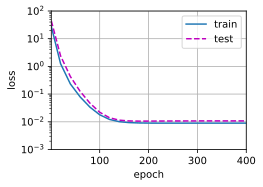

In [10]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

#### 4.4.4.4 Linear Fit

weight: [[3.392948  3.7927344]]


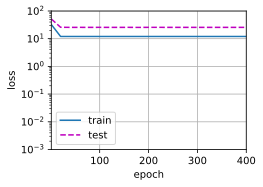

In [11]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

#### 4.4.4.5 High Order Polynomial Fit

weight: [[ 4.9992876   1.3255641  -3.4278488   5.0253377   0.06156929  1.3401879
   0.19970535  0.35797822  0.19683686 -0.12138204 -0.21490195 -0.0775269
  -0.06721605  0.21723238 -0.01437144 -0.16635521  0.15112883  0.06910849
   0.1133869  -0.03289577]]


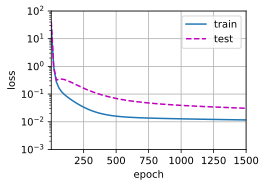

In [12]:
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:], num_epochs=1500)